In [9]:
import os
import sys

os.environ["XDG_SESSION_TYPE"] = "x11"
os.environ["OPEN3D_DISABLE_WEB_VISUALIZER"] = "true"     

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

sys.path.append('../src')
from models import canonical_model_name, get_most_epochs_file
from stats import load_training_stats

In [2]:
from consts import OUTPUT_DIR

STATS_DIR = OUTPUT_DIR / "stats"

In [18]:
MODEL_NAME = canonical_model_name(
    "QueryInGat(in_dim=384,query_dim=384,hidden_dims=[64,64,64,64],edge_dim=384,out_dim=1,heads=10)"
)

In [19]:
def load_model_stats(model_name: str):
    model_stats_dir = STATS_DIR / model_name
    most_epochs = get_most_epochs_file(model_stats_dir)
    print(model_stats_dir / (str(most_epochs) + ".h5"))
    return load_training_stats(model_stats_dir / (str(most_epochs) + ".h5"))

In [20]:
stats = load_model_stats(MODEL_NAME)
stats

/home/albert_kwok/ProgrammingWork/GeometricDeepLearning/3dsg_reader/notebooks/../outputs/stats/QueryInGat(edge_dim=384,heads=10,hidden_dims=[64,64,64,64],in_dim=384,out_dim=1,query_dim=384)/1000.h5


{'loss': array([0.08625478, 0.08650668, 0.08625102, 0.08598295, 0.08550434,
        0.08451673, 0.08308539, 0.0819829 , 0.08109831, 0.08015002,
        0.07953486, 0.07873221, 0.07824445, 0.07773244, 0.07709868,
        0.07674923, 0.07642103, 0.07625714, 0.0758635 , 0.07549835,
        0.07512988, 0.07463354, 0.07432841, 0.07403392, 0.07373552,
        0.07343586, 0.0732136 , 0.07289718, 0.07268186, 0.07262663,
        0.07231921, 0.0722739 , 0.07187328, 0.07157667, 0.07157727,
        0.07115281, 0.07104065, 0.07102842, 0.07090499, 0.07085689,
        0.07060347, 0.07146402, 0.07143863, 0.07093606, 0.07073955,
        0.0704304 , 0.07058005, 0.07048077, 0.07079988, 0.07049168,
        0.07034922, 0.06990228, 0.0701268 , 0.07008073, 0.06984915,
        0.06982159, 0.06976862, 0.06952308, 0.06920192, 0.06907959,
        0.06924091, 0.06922712, 0.06894054, 0.0687688 , 0.06877776,
        0.06885469, 0.06897324, 0.068846  , 0.06892588, 0.0696989 ,
        0.07235604, 0.0706446 , 0.070617

In [21]:
def plot_stats(training_stats, figsize=(10, 50), name=""):
    """ Create one plot for each metric stored in training_stats
    """
    stats_names = list(training_stats.keys())
    f, ax = plt.subplots(len(stats_names), 1, figsize=figsize)
    if len(stats_names)==1:
        ax = np.array([ax])
    for key, axx in zip(stats_names, ax.reshape(-1,)):
        axx.plot(
            range(1, len(training_stats[key]) + 1),
            training_stats[key],
            label=key)
        axx.set_xlabel("Training epoch")
        axx.set_ylabel(key)
        axx.legend()
    plt.title(name)

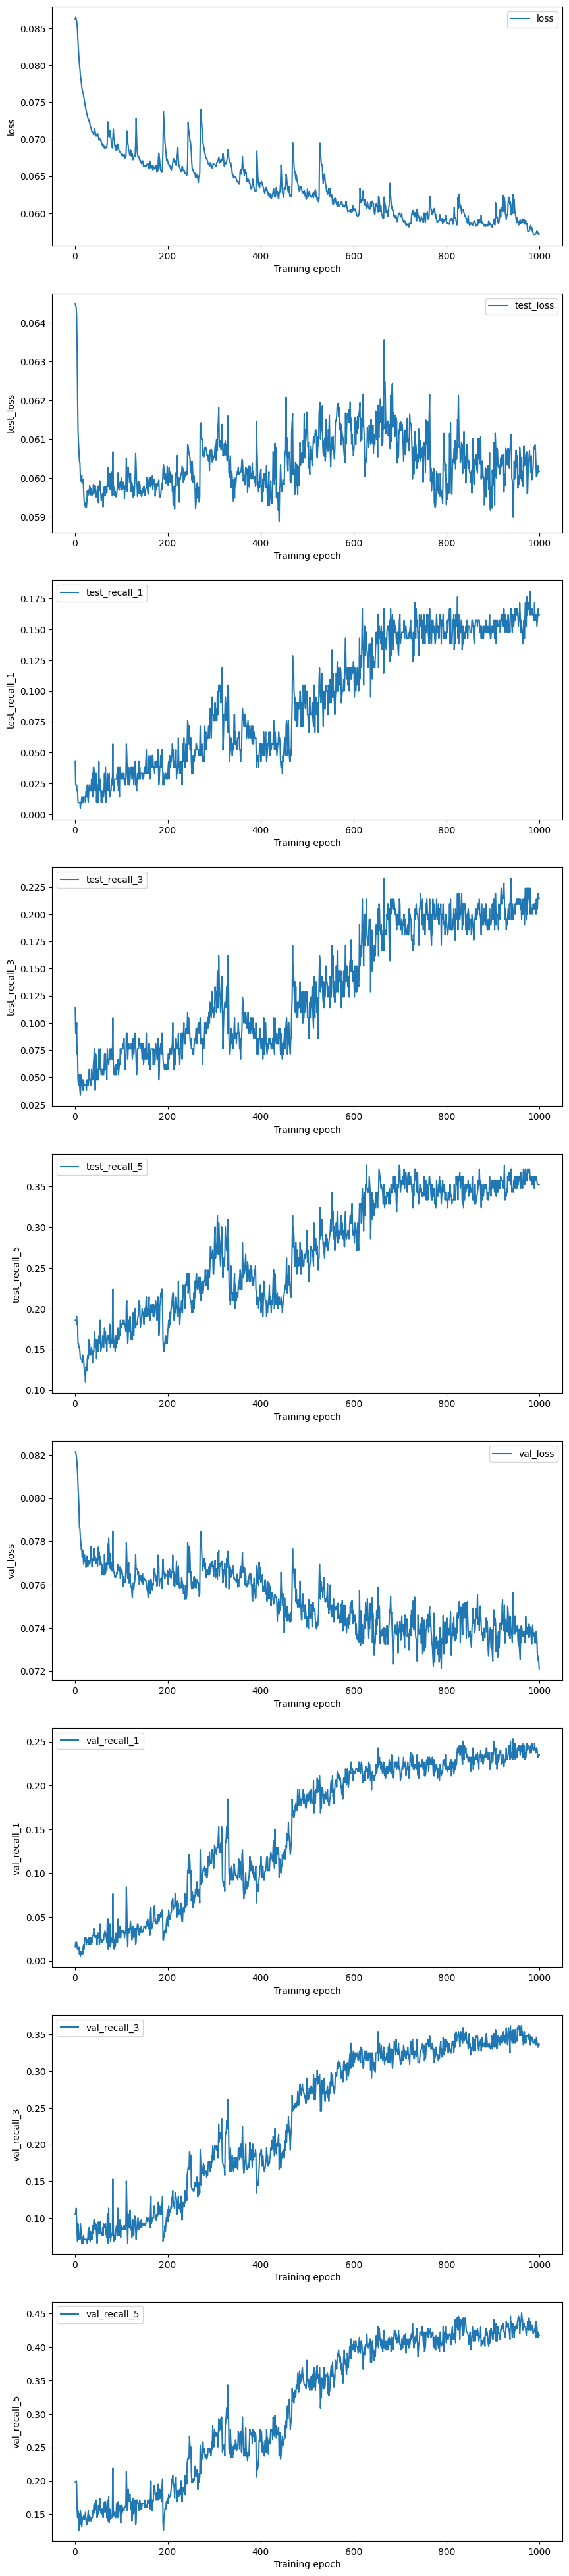

In [22]:
plot_stats(stats)